In [ ]:
!pip install ripser

# 1. BVP -> TPV

In [2]:
import os
import glob
import numpy as np
import pandas as pd

from ripser import ripser
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/Stress-Predict-Dataset/Raw_data"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/BVP_TPV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"S17"}

FS_BVP = 64
FS_ACC = 32

WINDOW_SEC = 60
STEP_SEC = 60
MAJORITY_RATIO_MIN = 0.95

# ---- BVP filter ----
LOWCUT = 0.5
HIGHCUT = 8.0
FILTER_ORDER = 4

# ---- Hard reject thresholds ----
FLATLINE_EPS = 1e-3
FLATLINE_MIN_SEC = 1.0
CLIPPING_RATIO_MAX = 0.10
MIN_PEAKS_PER_MIN = 30

# ---- Relaxed QC thresholds ----
VBR_MIN = 0.70
TC_MIN = 0.75
IBI_PASS_MIN = 0.80
MOTION_PERCENTILE = 80

# ---- Peak / beat extraction ----
MIN_HR_BPM = 40
MAX_HR_BPM = 180
MIN_PEAK_DISTANCE_SEC = 60.0 / MAX_HR_BPM
IBI_MIN_SEC = 0.30
IBI_MAX_SEC = 1.50

BEAT_BEFORE_SEC = 0.25
BEAT_AFTER_SEC = 0.45
BEAT_RESAMPLED_LEN = 100

# ---- Motion artifact thresholds ----
ALLOW_MISSING = False
ACC_DIFF_THRESH = 0.05
PSD_CORR_THRESH = 0.90
PSD_FMIN = 0.5
PSD_FMAX = 8.0

SELECTED_TPV_INDICES = [22, 9, 4, 2, 0, 28, 8, 19, 14, 26, 11]

TPV_FEATURE_NAMES = [
    "birth_mean", "birth_std", "death_mean", "death_std",
    "lifetime_mean", "lifetime_std", "lifetime_max", "lifetime_min",
    "lifetime_median", "lifetime_iqr", "lifetime_skew", "lifetime_kurtosis",
    "birth_max", "birth_min", "birth_median", "birth_skew", "birth_kurtosis",
    "death_max", "death_min", "death_median", "death_skew", "death_kurtosis",
    "num_lifetimes", "top1_lifetime", "top2_lifetime", "lifetime_max_div_min",
    "ph_entropy", "betti_entropy", "avg_persistence_distance", "gini_index",
    "lifetime_variance", "persistent_image_energy",
]
N_FEATURES = len(TPV_FEATURE_NAMES)

# =============================================================================
# Loaders
# =============================================================================
def load_empatica_signal_csv(file_path, signal_name):
    raw = pd.read_csv(file_path, header=None)
    start_ts = float(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])
    values = raw.iloc[2:, 0].astype(float).reset_index(drop=True)
    timestamps = start_ts + np.arange(len(values)) / fs
    df = pd.DataFrame({"timestamp": timestamps, signal_name: values})
    return df, start_ts, fs

def load_tags_csv(file_path, drop_first_tag=True):
    raw = pd.read_csv(file_path, header=None)
    tags = raw.iloc[:, 0].dropna().astype(float).reset_index(drop=True)

    if drop_first_tag:
        if len(tags) <= 1:
            raise ValueError(f"Not enough tags after dropping first tag: n={len(tags)}")
        tags = tags.iloc[1:].reset_index(drop=True)

    return pd.DataFrame({
        "tag_idx": np.arange(len(tags)),
        "timestamp": tags
    })

def load_acc_csv(file_path):
    raw = pd.read_csv(file_path, header=None)
    start_ts = float(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])
    data = raw.iloc[2:, :3].astype(float).reset_index(drop=True)
    timestamps = start_ts + np.arange(len(data)) / fs
    df = pd.DataFrame({
        "timestamp": timestamps,
        "acc_x": data.iloc[:, 0].values,
        "acc_y": data.iloc[:, 1].values,
        "acc_z": data.iloc[:, 2].values
    })
    return df, start_ts, fs

# =============================================================================
# Protocol intervals
# =============================================================================
def build_protocol_intervals(tags_df):
    timestamps = tags_df["timestamp"].values

    phase_info = [
        ("Baseline", 0),
        ("Stroop", 1),
        ("Rest1", 0),
        ("TSST", 1),
        ("Rest2", 0),
        ("Hyperventilation", 1),
        ("Rest3", 0),
        ("Questionnaire", 0),
    ]

    n_intervals_possible = len(timestamps) - 1
    n_use = min(n_intervals_possible, len(phase_info))
    if n_use <= 0:
        raise ValueError(f"No valid intervals from tags. n_tags={len(timestamps)}")

    rows = []
    for i in range(n_use):
        phase_name, label = phase_info[i]
        rows.append({
            "interval_idx": i,
            "phase": phase_name,
            "start": timestamps[i],
            "end": timestamps[i + 1],
            "label": label
        })

    return pd.DataFrame(rows)

def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60, majority_ratio_min=0.95):
    rows = []
    for _, r in intervals_df.iterrows():
        phase = r["phase"]
        label = int(r["label"])
        start = float(r["start"])
        end = float(r["end"])

        t = start
        while t + window_sec <= end:
            major_ratio = 1.0
            if major_ratio >= majority_ratio_min:
                rows.append({
                    "phase": phase,
                    "label": label,
                    "window_start": t,
                    "window_end": t + window_sec,
                    "major_ratio": major_ratio
                })
            t += step_sec

    return pd.DataFrame(rows)

# =============================================================================
# Basic utils
# =============================================================================
def fill_nan_with_median(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x

def fill_nan_acc_with_median(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32).copy()
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return acc_xyz
    for c in range(3):
        ch = acc_xyz[:, c]
        med = np.nanmedian(ch)
        if np.isnan(med):
            med = 0.0
        acc_xyz[:, c] = np.nan_to_num(ch, nan=med, posinf=med, neginf=med)
    return acc_xyz

def bandpass_filter(sig, fs=64, low=0.5, high=8.0, order=4):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)

def zscore_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mu) / (sd + 1e-8)).astype(np.float32)

def safe_skew(x):
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0

def safe_kurtosis(x):
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0

def clamp01(x):
    return float(np.clip(x, 0.0, 1.0))

def compute_missing_ratio(x):
    x = np.asarray(x)
    return float(np.mean(~np.isfinite(x)))

# =============================================================================
# TPV extraction
# =============================================================================
def extract_tpv_features(sig_1d):
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(N_FEATURES, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(N_FEATURES, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)
    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]

    if H1.size == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births = births[mask]
    deaths = deaths[mask]
    lifetimes = lifetimes[mask]

    if len(lifetimes) == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)
    lifetime_sum = float(np.sum(lifetimes))
    lifetime_ratio = lifetimes / (lifetime_sum + 1e-8)
    ph_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin = float(np.min(births))
    bmax = float(np.max(births))
    if bmax - bmin < 1e-8:
        betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        betti_entropy = float(entropy(hist + 1e-10))

    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2 * np.sum(np.arange(1, n + 1) * lifetimes_sorted)) / (n * np.sum(lifetimes_sorted)) - (n + 1) / n
        gini_index = float(gini)
    else:
        gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))
    persistent_image_energy = float(np.sum(lifetimes ** 2))

    feats = [
        float(np.mean(births)),
        float(np.std(births)),
        float(np.mean(deaths)),
        float(np.std(deaths)),
        float(np.mean(lifetimes)),
        float(np.std(lifetimes)),
        float(np.max(lifetimes)),
        float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        safe_skew(lifetimes),
        safe_kurtosis(lifetimes),
        float(np.max(births)),
        float(np.min(births)),
        float(np.median(births)),
        safe_skew(births),
        safe_kurtosis(births),
        float(np.max(deaths)),
        float(np.min(deaths)),
        float(np.median(deaths)),
        safe_skew(deaths),
        safe_kurtosis(deaths),
        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        ph_entropy,
        betti_entropy,
        avg_persistence_distance,
        gini_index,
        lifetime_variance,
        persistent_image_energy,
    ]
    return np.asarray(feats, dtype=np.float32)

# =============================================================================
# QC helpers
# =============================================================================
def is_flatline(sig, fs, eps=FLATLINE_EPS, min_sec=FLATLINE_MIN_SEC):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    run_len = int(round(fs * min_sec))
    if len(sig) < run_len:
        return False
    ds = np.abs(np.diff(sig))
    low_change = ds < eps
    cnt = 0
    for v in low_change:
        if v:
            cnt += 1
            if cnt >= run_len - 1:
                return True
        else:
            cnt = 0
    return False

def clipping_ratio(sig):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    if len(sig) == 0:
        return 1.0
    lo = np.percentile(sig, 1)
    hi = np.percentile(sig, 99)
    if hi - lo < 1e-8:
        return 1.0
    near_lo = sig <= (lo + 0.01 * (hi - lo))
    near_hi = sig >= (hi - 0.01 * (hi - lo))
    return float(np.mean(near_lo | near_hi))

def detect_ppg_peaks(sig, fs):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    distance = max(1, int(round(MIN_PEAK_DISTANCE_SEC * fs)))
    prom = max(0.10, 0.20 * float(np.std(sig)))
    peaks, props = find_peaks(sig, distance=distance, prominence=prom)
    return peaks, props

def compute_motion_score(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return 1.0
    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    return float(np.median(dmag) + 0.5 * np.std(dmag))

def compute_acc_diff_metrics(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return {"acc_diff_mean": np.nan, "acc_diff_exceed_ratio": np.nan, "acc_diff_flag": 1}

    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    acc_diff_mean = float(np.mean(dmag)) if len(dmag) > 0 else 0.0
    acc_diff_exceed_ratio = float(np.mean(dmag > ACC_DIFF_THRESH)) if len(dmag) > 0 else 0.0
    acc_diff_flag = int(acc_diff_mean > ACC_DIFF_THRESH)
    return {
        "acc_diff_mean": acc_diff_mean,
        "acc_diff_exceed_ratio": acc_diff_exceed_ratio,
        "acc_diff_flag": acc_diff_flag
    }

def _safe_psd_1d(x, fs, fmin, fmax):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) < 8:
        return None, None
    x = x[np.isfinite(x)]
    if len(x) < 8 or np.std(x) < 1e-8:
        return None, None
    nperseg = min(256, len(x))
    f, pxx = welch(x, fs=fs, nperseg=nperseg)
    mask = (f >= fmin) & (f <= min(fmax, fs / 2 - 1e-6))
    if np.sum(mask) < 4:
        return None, None
    return f[mask], pxx[mask]

def _corr_on_common_freq(f_ref, p_ref, f_other, p_other):
    if f_ref is None or f_other is None:
        return np.nan
    p_other_interp = np.interp(f_ref, f_other, p_other)
    a = np.log1p(p_ref)
    b = np.log1p(p_other_interp)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return np.nan
    r = np.corrcoef(a, b)[0, 1]
    return float(r) if np.isfinite(r) else np.nan

def compute_bvp_acc_psd_corr(seg_bvp_bp, seg_acc_xyz, fs_bvp, fs_acc, fmin=PSD_FMIN, fmax=PSD_FMAX):
    out = {
        "psd_corr_x": np.nan, "psd_corr_y": np.nan, "psd_corr_z": np.nan,
        "psd_corr_mag": np.nan, "psd_corr_max": np.nan, "psd_corr_flag": 1
    }
    seg_bvp_bp = np.asarray(seg_bvp_bp, dtype=np.float32).reshape(-1)
    acc_xyz = np.asarray(seg_acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return out

    f_bvp, p_bvp = _safe_psd_1d(seg_bvp_bp, fs_bvp, fmin, fmax)
    if f_bvp is None:
        return out

    acc_mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    corr_list = []
    for name, sig in [("x", acc_xyz[:, 0]), ("y", acc_xyz[:, 1]), ("z", acc_xyz[:, 2]), ("mag", acc_mag)]:
        f_acc, p_acc = _safe_psd_1d(sig, fs_acc, fmin, fmax)
        r = _corr_on_common_freq(f_bvp, p_bvp, f_acc, p_acc)
        out[f"psd_corr_{name}"] = r
        if np.isfinite(r):
            corr_list.append(r)

    if len(corr_list) == 0:
        return out
    out["psd_corr_max"] = float(np.max(corr_list))
    out["psd_corr_flag"] = int(out["psd_corr_max"] >= PSD_CORR_THRESH)
    return out

def extract_beats(sig, peaks, fs):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    beats = []
    before = int(round(BEAT_BEFORE_SEC * fs))
    after = int(round(BEAT_AFTER_SEC * fs))
    target_x = np.linspace(0, 1, BEAT_RESAMPLED_LEN)

    for p in peaks:
        s = p - before
        e = p + after
        if s < 0 or e > len(sig):
            continue
        beat = sig[s:e].copy()
        if len(beat) < 5:
            continue
        src_x = np.linspace(0, 1, len(beat))
        f = interp1d(src_x, beat, kind="linear")
        beats.append(f(target_x).astype(np.float32))

    if len(beats) == 0:
        return np.empty((0, BEAT_RESAMPLED_LEN), dtype=np.float32)
    return np.stack(beats, axis=0)

def median_template_corr(beats):
    if beats.ndim != 2 or len(beats) < 2:
        return 0.0
    template = np.median(beats, axis=0)
    vals = []
    for b in beats:
        if np.std(b) < 1e-8 or np.std(template) < 1e-8:
            vals.append(0.0)
        else:
            r = np.corrcoef(b, template)[0, 1]
            vals.append(float(r) if np.isfinite(r) else 0.0)
    return float(np.median(vals)) if len(vals) > 0 else 0.0

def compute_ibi_metrics(peaks, fs):
    peaks = np.asarray(peaks, dtype=np.int64)
    if len(peaks) < 3:
        return {
            "n_peaks": int(len(peaks)),
            "ibi_pass_ratio": 0.0,
            "valid_beat_ratio": 0.0,
            "ibi_plausibility": 0.0,
            "ibi_mean_sec": np.nan,
        }

    ibi = np.diff(peaks) / float(fs)
    plausible = (ibi >= IBI_MIN_SEC) & (ibi <= IBI_MAX_SEC)
    ibi_pass_ratio = float(np.mean(plausible)) if len(ibi) > 0 else 0.0

    if len(ibi) >= 3:
        med_ibi = np.median(ibi)
        valid = plausible & (np.abs(ibi - med_ibi) <= 0.30 * (med_ibi + 1e-8))
        vbr = float(np.mean(valid))
    else:
        vbr = ibi_pass_ratio

    return {
        "n_peaks": int(len(peaks)),
        "ibi_pass_ratio": ibi_pass_ratio,
        "valid_beat_ratio": vbr,
        "ibi_plausibility": ibi_pass_ratio,
        "ibi_mean_sec": float(np.mean(ibi)) if len(ibi) > 0 else np.nan,
    }

def notch_foot_peak_detectability_score(beats):
    if beats.ndim != 2 or len(beats) == 0:
        return 0.0
    scores = []
    for b in beats:
        foot = np.min(b[:max(5, len(b)//4)])
        peak = np.max(b)
        amp = peak - foot
        dyn = np.max(b) - np.min(b) + 1e-8
        scores.append(clamp01(amp / dyn))
    return float(np.median(scores)) if len(scores) > 0 else 0.0

def compute_sqi_scores(vbr, tc, ibi_plausibility, motion_score, morph_score):
    motion_penalty = clamp01(motion_score)
    sqi_stress_basic = (
        0.40 * clamp01(vbr) +
        0.30 * clamp01(tc) +
        0.20 * clamp01(ibi_plausibility) -
        0.10 * motion_penalty
    )
    sqi_stress_morph = (
        0.30 * clamp01(vbr) +
        0.25 * clamp01(tc) +
        0.20 * clamp01(ibi_plausibility) +
        0.25 * clamp01(morph_score) -
        motion_penalty
    )
    return float(sqi_stress_basic), float(sqi_stress_morph), motion_penalty

def evaluate_window_quality(seg_bvp_raw, seg_acc_xyz, fs_bvp, fs_acc):
    out = {}

    out["bvp_missing_ratio"] = compute_missing_ratio(seg_bvp_raw)
    out["acc_missing_ratio"] = compute_missing_ratio(seg_acc_xyz)
    out["missing_flag"] = int(
        (out["bvp_missing_ratio"] > 0.0) or
        (out["acc_missing_ratio"] > 0.0)
    ) if not ALLOW_MISSING else 0

    seg_bvp = fill_nan_with_median(seg_bvp_raw)
    seg_acc_xyz = fill_nan_acc_with_median(seg_acc_xyz)

    seg_bvp_bp = bandpass_filter(seg_bvp, fs=fs_bvp, low=LOWCUT, high=HIGHCUT, order=FILTER_ORDER)
    seg_bvp_z = zscore_1d(seg_bvp_bp)

    out["flatline_flag"] = int(is_flatline(seg_bvp_bp, fs=fs_bvp))
    out["clipping_ratio"] = clipping_ratio(seg_bvp_bp)
    out["clipping_flag"] = int(out["clipping_ratio"] > CLIPPING_RATIO_MAX)

    peaks, _ = detect_ppg_peaks(seg_bvp_z, fs=fs_bvp)
    out["n_peaks"] = int(len(peaks))
    out["peak_sparse_flag"] = int(len(peaks) < MIN_PEAKS_PER_MIN)

    ibi_info = compute_ibi_metrics(peaks, fs_bvp)
    out.update(ibi_info)

    beats = extract_beats(seg_bvp_z, peaks, fs_bvp)
    tc = median_template_corr(beats)
    morph_score = notch_foot_peak_detectability_score(beats)
    motion_score_raw = compute_motion_score(seg_acc_xyz)

    out["median_template_corr"] = float(tc)
    out["notch_foot_peak_detectability"] = float(morph_score)
    out["motion_score_raw"] = float(motion_score_raw)

    sqi_basic, sqi_morph, motion_penalty = compute_sqi_scores(
        vbr=out["valid_beat_ratio"],
        tc=tc,
        ibi_plausibility=out["ibi_plausibility"],
        motion_score=motion_score_raw,
        morph_score=morph_score
    )
    out["motion_score"] = float(motion_penalty)
    out["SQI_stress_basic"] = float(sqi_basic)
    out["SQI_stress_morph"] = float(sqi_morph)

    acc_diff_info = compute_acc_diff_metrics(seg_acc_xyz)
    out.update(acc_diff_info)

    psd_corr_info = compute_bvp_acc_psd_corr(seg_bvp_bp, seg_acc_xyz, fs_bvp, fs_acc)
    out.update(psd_corr_info)

    hard_reject = (
        (out["missing_flag"] == 1) or
        (out["flatline_flag"] == 1) or
        (out["clipping_flag"] == 1) or
        (out["peak_sparse_flag"] == 1) or
        (out["acc_diff_flag"] == 1) or
        (out["psd_corr_flag"] == 1)
    )
    out["hard_reject"] = int(hard_reject)

    return seg_bvp_z, out

# =============================================================================
# Main extraction
# =============================================================================
def extract_subject_bvp_tpv(subject_dir):
    subject_id = os.path.basename(subject_dir)
    if subject_id in EXCLUDE_SUBJECTS:
        return pd.DataFrame()

    bvp_path = os.path.join(subject_dir, "BVP.csv")
    acc_path = os.path.join(subject_dir, "ACC.csv")
    tags_path = os.path.join(subject_dir, f"tags_{subject_id}.csv")

    if not (os.path.exists(bvp_path) and os.path.exists(acc_path) and os.path.exists(tags_path)):
        return pd.DataFrame()

    bvp_df, _, fs_bvp = load_empatica_signal_csv(bvp_path, "bvp")
    acc_df, _, fs_acc = load_acc_csv(acc_path)
    tags_df = load_tags_csv(tags_path, drop_first_tag=True)

    if len(tags_df) < 2:
        print(f"[WARN] {subject_id}: too few tags after dropping first tag")
        return pd.DataFrame()

    if int(round(fs_bvp)) != FS_BVP or int(round(fs_acc)) != FS_ACC:
        print(f"[WARN] {subject_id}: fs mismatch BVP={fs_bvp}, ACC={fs_acc}")

    intervals_df = build_protocol_intervals(tags_df)
    window_df = build_window_table_from_intervals(
        intervals_df,
        window_sec=WINDOW_SEC,
        step_sec=STEP_SEC,
        majority_ratio_min=MAJORITY_RATIO_MIN
    )

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        seg_bvp = bvp_df[(bvp_df["timestamp"] >= t0) & (bvp_df["timestamp"] < t1)]["bvp"].values
        seg_acc = acc_df[(acc_df["timestamp"] >= t0) & (acc_df["timestamp"] < t1)][["acc_x", "acc_y", "acc_z"]].values

        if len(seg_bvp) != WINDOW_SEC * FS_BVP:
            continue
        if len(seg_acc) != WINDOW_SEC * FS_ACC:
            continue

        seg_bvp_for_tpv, qc_info = evaluate_window_quality(seg_bvp, seg_acc, FS_BVP, FS_ACC)
        tpv_full = extract_tpv_features(seg_bvp_for_tpv)

        window_counter += 1
        row = {
            "subject": subject_id,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": int(w["label"]),
            "status_name": "stress" if int(w["label"]) == 1 else "normal",
            "phase": w["phase"],
            "t_start_sec": t0,
            "t_end_sec": t1,
            "major_ratio": float(w["major_ratio"])
        }

        row.update(qc_info)
        for idx in SELECTED_TPV_INDICES:
            row[f"TPV{idx}"] = float(tpv_full[idx])

        rows.append(row)

    return pd.DataFrame(rows)

def apply_relaxed_personalized_qc(df):
    df = df.copy()
    if len(df) == 0:
        return df

    motion_thr_map = (
        df.groupby("subject")["motion_score"]
        .quantile(MOTION_PERCENTILE / 100.0)
        .to_dict()
    )
    df["motion_threshold_subject_p80"] = df["subject"].map(motion_thr_map)

    df["qc_relaxed_pass"] = (
        (df["hard_reject"] == 0) &
        (df["valid_beat_ratio"] >= VBR_MIN) &
        (df["median_template_corr"] >= TC_MIN) &
        (df["ibi_pass_ratio"] >= IBI_PASS_MIN) &
        (df["motion_score"] <= df["motion_threshold_subject_p80"])
    ).astype(int)

    return df

def main():
    subject_dirs = sorted([d for d in glob.glob(os.path.join(ROOT_DIR, "S*")) if os.path.isdir(d)])
    all_dfs = []

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    for subject_dir in subject_dirs:
        sid = os.path.basename(subject_dir)
        if sid in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {sid}")
            continue
        print(f"[INFO] Processing {sid} ...")
        try:
            df_sub = extract_subject_bvp_tpv(subject_dir)
            print(f"[INFO] {sid}: extracted {len(df_sub)} windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {sid}: {e}")

    if len(all_dfs) == 0:
        print("[WARN] No windows extracted.")
        return

    df_all = pd.concat(all_dfs, axis=0, ignore_index=True)
    df_all = apply_relaxed_personalized_qc(df_all)

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "phase",
        "t_start_sec", "t_end_sec", "major_ratio"
    ]
    qc_cols = [
        "bvp_missing_ratio", "acc_missing_ratio", "missing_flag",
        "flatline_flag", "clipping_ratio", "clipping_flag",
        "n_peaks", "peak_sparse_flag",
        "ibi_pass_ratio", "valid_beat_ratio", "ibi_plausibility", "ibi_mean_sec",
        "median_template_corr", "notch_foot_peak_detectability",
        "acc_diff_mean", "acc_diff_exceed_ratio", "acc_diff_flag",
        "psd_corr_x", "psd_corr_y", "psd_corr_z", "psd_corr_mag",
        "psd_corr_max", "psd_corr_flag",
        "motion_score_raw", "motion_score",
        "SQI_stress_basic", "SQI_stress_morph",
        "hard_reject", "motion_threshold_subject_p80", "qc_relaxed_pass"
    ]
    feat_cols = [f"TPV{idx}" for idx in SELECTED_TPV_INDICES]

    final_cols = base_cols + qc_cols + feat_cols
    df_all = df_all[final_cols].copy()

    csv_all = os.path.join(OUTPUT_DIR, "StressPredict_BVP_TPV_noQC.csv")
    df_all.to_csv(csv_all, index=False)

    df_qc = df_all[df_all["qc_relaxed_pass"] == 1].copy()
    csv_qc = os.path.join(OUTPUT_DIR, "StressPredict_BVP_TPV_withQC.csv")
    df_qc.to_csv(csv_qc, index=False)

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_total=("window", "count"),
            n_qc_pass=("qc_relaxed_pass", "sum")
        )
        .reset_index()
    )
    summary["retention_ratio"] = summary["n_qc_pass"] / summary["n_total"]
    summary_csv = os.path.join(OUTPUT_DIR, "StressPredict_BVP_TPV_summary.csv")
    summary.to_csv(summary_csv, index=False)

    print(f"[INFO] Saved: {csv_all}")
    print(f"[INFO] Saved: {csv_qc}")
    print(f"[INFO] Saved: {summary_csv}")
    print("\n[INFO] Status counts (all)")
    print(df_all["status_name"].value_counts())
    print("\n[INFO] Status counts (QC)")
    print(df_qc["status_name"].value_counts())

if __name__ == "__main__":
    main()

[INFO] Found 35 subject folders
[INFO] Processing S01 ...
[INFO] S01: extracted 44 windows
[INFO] Processing S02 ...
[INFO] S02: extracted 40 windows
[INFO] Processing S03 ...
[INFO] S03: extracted 38 windows
[INFO] Processing S04 ...
[INFO] S04: extracted 40 windows
[INFO] Processing S05 ...
[INFO] S05: extracted 25 windows
[INFO] Processing S06 ...
[INFO] S06: extracted 25 windows
[INFO] Processing S07 ...
[INFO] S07: extracted 26 windows
[INFO] Processing S08 ...
[INFO] S08: extracted 23 windows
[INFO] Processing S09 ...
[INFO] S09: extracted 25 windows
[INFO] Processing S10 ...
[INFO] S10: extracted 25 windows
[INFO] Processing S11 ...
[INFO] S11: extracted 25 windows
[INFO] Processing S12 ...
[INFO] S12: extracted 25 windows
[INFO] Processing S13 ...
[INFO] S13: extracted 26 windows
[INFO] Processing S14 ...
[INFO] S14: extracted 26 windows
[INFO] Processing S15 ...
[INFO] S15: extracted 28 windows
[INFO] Processing S16 ...
[INFO] S16: extracted 26 windows
[INFO] Skip excluded sub

Total TPV features: 11


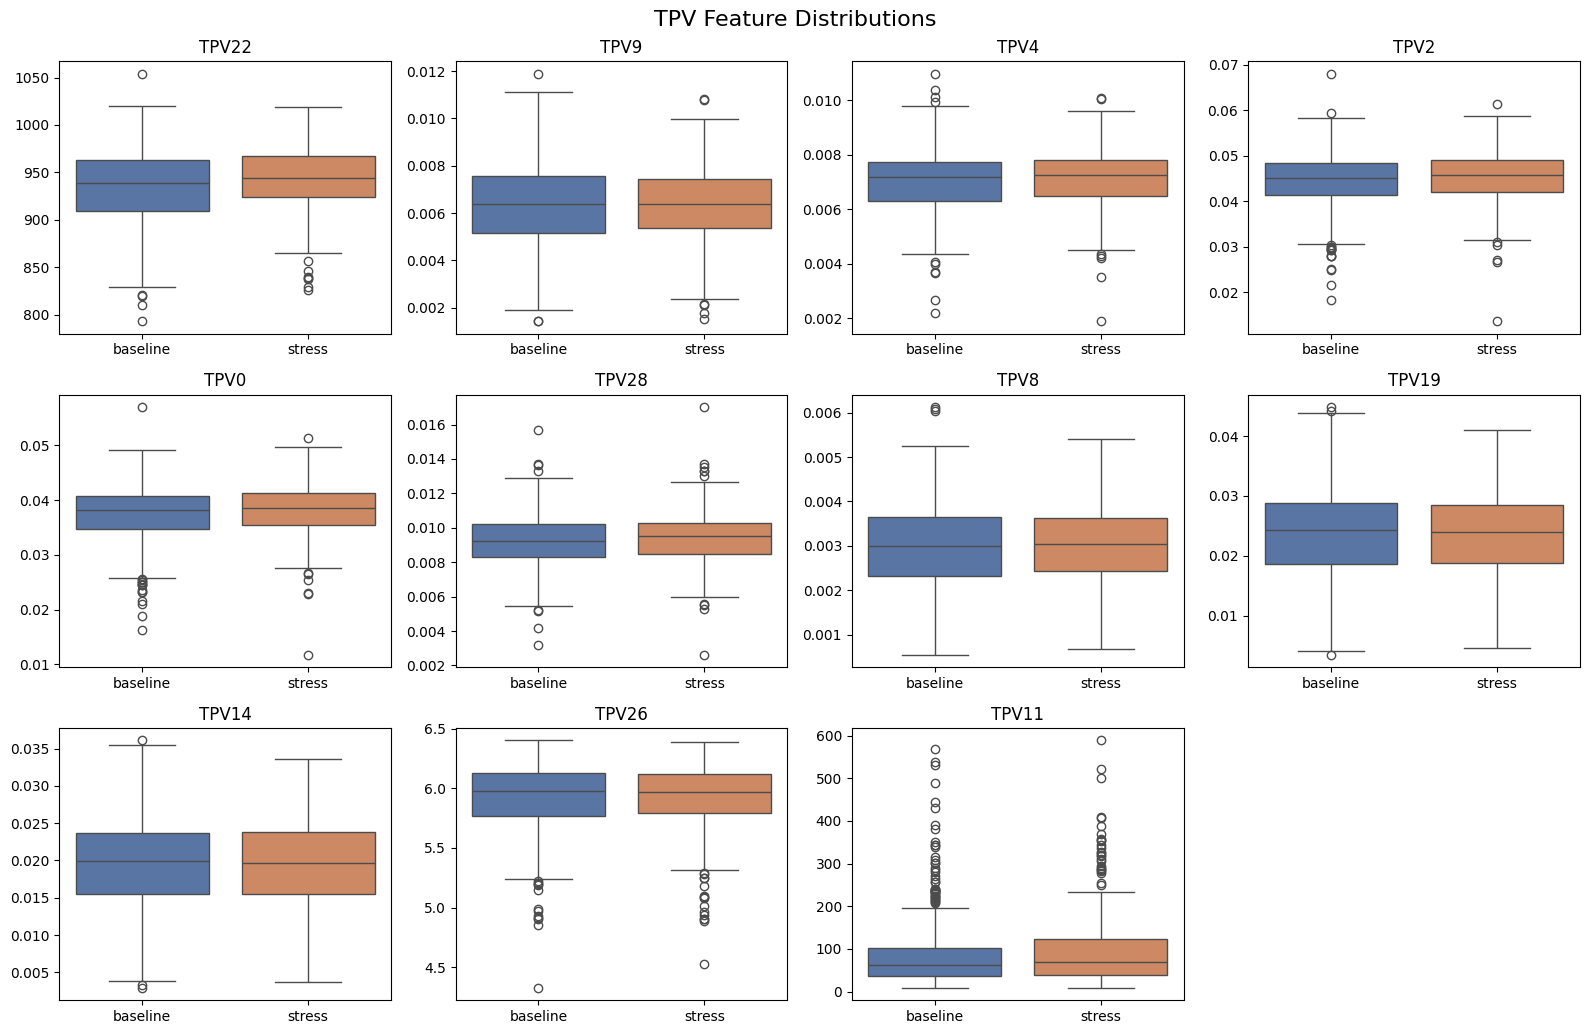


===== TPV Feature Summary =====
feature Baseline (mean±std) Stress (mean±std)         direction  anova_p
  TPV22    933.960 ± 39.890  942.762 ± 32.817 stress > baseline 0.000407
   TPV0       0.037 ± 0.005     0.038 ± 0.005 stress > baseline 0.016020
   TPV2       0.044 ± 0.006     0.045 ± 0.006 stress > baseline 0.023736
  TPV11     85.174 ± 80.083   96.294 ± 87.018 stress > baseline 0.046113
  TPV28       0.009 ± 0.002     0.009 ± 0.002 stress > baseline 0.097119
   TPV4       0.007 ± 0.001     0.007 ± 0.001 stress > baseline 0.204261
  TPV26       5.924 ± 0.288     5.915 ± 0.284 stress < baseline 0.651130
   TPV9       0.006 ± 0.002     0.006 ± 0.002 stress > baseline 0.755977
   TPV8       0.003 ± 0.001     0.003 ± 0.001 stress > baseline 0.768389
  TPV19       0.024 ± 0.007     0.024 ± 0.007 stress < baseline 0.929463
  TPV14       0.019 ± 0.006     0.019 ± 0.006 stress < baseline 0.999606


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import f_oneway

# -------------------------
# load
# -------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/BVP_TPV/StressPredict_BVP_TPV_noQC.csv")

# -------------------------
# state mapping (자동 처리)
# -------------------------
if "status_name" in df.columns:
    df["state"] = df["status_name"].replace({
        "normal": "baseline",
        "stress": "stress"
    })
else:
    df["state"] = df["label_major"].map({
        0: "baseline",
        1: "stress"
    })

# -------------------------
# TPV feature 자동 탐색
# -------------------------
tpv_features = [c for c in df.columns if c.startswith("TPV")]

print(f"Total TPV features: {len(tpv_features)}")

results = []

# -------------------------
# Boxplot
# -------------------------
n_features = len(tpv_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]

    anova = f_oneway(b, s)
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"],
        "baseline_std": summary.loc["baseline", "std"],
        "stress_mean": summary.loc["stress", "mean"],
        "stress_std": summary.loc["stress", "std"],
        "direction": "stress > baseline" if summary.loc["stress","mean"] > summary.loc["baseline","mean"] else "stress < baseline",
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("TPV Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df = results_df[
    ["feature", "Baseline (mean±std)", "Stress (mean±std)", "direction", "anova_p"]
].sort_values("anova_p")

print("\n===== TPV Feature Summary =====")
print(results_df.to_string(index=False))

# 2. EDA -> TPV

In [3]:
import os
import glob
import numpy as np
import pandas as pd

from ripser import ripser
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/Stress-Predict-Dataset/Raw_data"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/StressPredict_outputs/EDA_TPV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"S17"}

FS_EDA = 4
FS_ACC = 32

WINDOW_SEC = 60
STEP_SEC = 60
MAJORITY_RATIO_MIN = 0.95

LOWCUT = 0.05
HIGHCUT = 1.0
FILTER_ORDER = 4

FLATLINE_EPS = 1e-4
FLATLINE_MIN_SEC = 3.0
CLIPPING_RATIO_MAX = 0.15
MIN_PEAKS_PER_MIN = 2

VBR_MIN = 0.30
TC_MIN = 0.30
IBI_PASS_MIN = 0.30
MOTION_PERCENTILE = 80

MIN_EVENT_DISTANCE_SEC = 1.0
IBI_MIN_SEC = 0.5
IBI_MAX_SEC = 10.0

BEAT_BEFORE_SEC = 1.0
BEAT_AFTER_SEC = 3.0
BEAT_RESAMPLED_LEN = 100

ALLOW_MISSING = False
ACC_DIFF_THRESH = 0.05
PSD_CORR_THRESH = 0.90
PSD_FMIN = 0.05
PSD_FMAX = 1.0

TPV_FEATURE_NAMES = [
    "birth_mean", "birth_std", "death_mean", "death_std",
    "lifetime_mean", "lifetime_std", "lifetime_max", "lifetime_min",
    "lifetime_median", "lifetime_iqr", "lifetime_skew", "lifetime_kurtosis",
    "birth_max", "birth_min", "birth_median", "birth_skew", "birth_kurtosis",
    "death_max", "death_min", "death_median", "death_skew", "death_kurtosis",
    "num_lifetimes", "top1_lifetime", "top2_lifetime", "lifetime_max_div_min",
    "ph_entropy", "betti_entropy", "avg_persistence_distance", "gini_index",
    "lifetime_variance", "persistent_image_energy",
]
N_FEATURES = len(TPV_FEATURE_NAMES)

# =============================================================================
# Loaders
# =============================================================================
def load_empatica_signal_csv(file_path, signal_name):
    raw = pd.read_csv(file_path, header=None)
    start_ts = float(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])
    values = raw.iloc[2:, 0].astype(float).reset_index(drop=True)
    timestamps = start_ts + np.arange(len(values)) / fs
    return pd.DataFrame({"timestamp": timestamps, signal_name: values}), start_ts, fs

def load_tags_csv(file_path, drop_first_tag=True):
    raw = pd.read_csv(file_path, header=None)
    tags = raw.iloc[:, 0].dropna().astype(float).reset_index(drop=True)

    if drop_first_tag:
        if len(tags) <= 1:
            raise ValueError(f"Not enough tags after dropping first tag: n={len(tags)}")
        tags = tags.iloc[1:].reset_index(drop=True)

    return pd.DataFrame({
        "tag_idx": np.arange(len(tags)),
        "timestamp": tags
    })

def load_acc_csv(file_path):
    raw = pd.read_csv(file_path, header=None)
    start_ts = float(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])
    data = raw.iloc[2:, :3].astype(float).reset_index(drop=True)
    timestamps = start_ts + np.arange(len(data)) / fs
    df = pd.DataFrame({
        "timestamp": timestamps,
        "acc_x": data.iloc[:, 0].values,
        "acc_y": data.iloc[:, 1].values,
        "acc_z": data.iloc[:, 2].values
    })
    return df, start_ts, fs

# =============================================================================
# Protocol intervals
# =============================================================================
def build_protocol_intervals(tags_df):
    timestamps = tags_df["timestamp"].values
    phase_info = [
        ("Baseline", 0),
        ("Stroop", 1),
        ("Rest1", 0),
        ("TSST", 1),
        ("Rest2", 0),
        ("Hyperventilation", 1),
        ("Rest3", 0),
        ("Questionnaire", 0),
    ]
    n_intervals_possible = len(timestamps) - 1
    n_use = min(n_intervals_possible, len(phase_info))
    if n_use <= 0:
        raise ValueError(f"No valid intervals from tags. n_tags={len(timestamps)}")

    rows = []
    for i in range(n_use):
        phase_name, label = phase_info[i]
        rows.append({
            "interval_idx": i,
            "phase": phase_name,
            "start": timestamps[i],
            "end": timestamps[i + 1],
            "label": label
        })
    return pd.DataFrame(rows)

def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60, majority_ratio_min=0.95):
    rows = []
    for _, r in intervals_df.iterrows():
        phase = r["phase"]
        label = int(r["label"])
        start = float(r["start"])
        end = float(r["end"])

        t = start
        while t + window_sec <= end:
            rows.append({
                "phase": phase,
                "label": label,
                "window_start": t,
                "window_end": t + window_sec,
                "major_ratio": 1.0
            })
            t += step_sec
    return pd.DataFrame(rows)

# =============================================================================
# Utils
# =============================================================================
def fill_nan_with_median(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x

def fill_nan_acc_with_median(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32).copy()
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return acc_xyz
    for c in range(3):
        ch = acc_xyz[:, c]
        med = np.nanmedian(ch)
        if np.isnan(med):
            med = 0.0
        acc_xyz[:, c] = np.nan_to_num(ch, nan=med, posinf=med, neginf=med)
    return acc_xyz

def bandpass_filter(sig, fs=4, low=0.05, high=1.0, order=4):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)

def zscore_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mu) / (sd + 1e-8)).astype(np.float32)

def safe_skew(x):
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0

def safe_kurtosis(x):
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0

def clamp01(x):
    return float(np.clip(x, 0.0, 1.0))

def compute_missing_ratio(x):
    x = np.asarray(x)
    return float(np.mean(~np.isfinite(x)))

# =============================================================================
# TPV
# =============================================================================
def extract_tpv_features(sig_1d):
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)
    if len(sig) < 3:
        return np.zeros(N_FEATURES, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(N_FEATURES, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)
    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]

    if H1.size == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births = births[mask]
    deaths = deaths[mask]
    lifetimes = lifetimes[mask]

    if len(lifetimes) == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)
    lifetime_sum = float(np.sum(lifetimes))
    lifetime_ratio = lifetimes / (lifetime_sum + 1e-8)
    ph_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin = float(np.min(births))
    bmax = float(np.max(births))
    if bmax - bmin < 1e-8:
        betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        betti_entropy = float(entropy(hist + 1e-10))

    avg_persistence_distance = float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (2 * np.sum(np.arange(1, n + 1) * lifetimes_sorted)) / (n * np.sum(lifetimes_sorted)) - (n + 1) / n
        gini_index = float(gini)
    else:
        gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))
    persistent_image_energy = float(np.sum(lifetimes ** 2))

    feats = [
        float(np.mean(births)),
        float(np.std(births)),
        float(np.mean(deaths)),
        float(np.std(deaths)),
        float(np.mean(lifetimes)),
        float(np.std(lifetimes)),
        float(np.max(lifetimes)),
        float(np.min(lifetimes)),
        float(np.median(lifetimes)),
        float(iqr(lifetimes)),
        safe_skew(lifetimes),
        safe_kurtosis(lifetimes),
        float(np.max(births)),
        float(np.min(births)),
        float(np.median(births)),
        safe_skew(births),
        safe_kurtosis(births),
        float(np.max(deaths)),
        float(np.min(deaths)),
        float(np.median(deaths)),
        safe_skew(deaths),
        safe_kurtosis(deaths),
        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        ph_entropy,
        betti_entropy,
        avg_persistence_distance,
        gini_index,
        lifetime_variance,
        persistent_image_energy,
    ]
    return np.asarray(feats, dtype=np.float32)

# =============================================================================
# QC
# =============================================================================
def is_flatline(sig, fs, eps=FLATLINE_EPS, min_sec=FLATLINE_MIN_SEC):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    run_len = int(round(fs * min_sec))
    if len(sig) < run_len:
        return False
    ds = np.abs(np.diff(sig))
    low_change = ds < eps
    cnt = 0
    for v in low_change:
        if v:
            cnt += 1
            if cnt >= run_len - 1:
                return True
        else:
            cnt = 0
    return False

def clipping_ratio(sig):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    if len(sig) == 0:
        return 1.0
    lo = np.percentile(sig, 1)
    hi = np.percentile(sig, 99)
    if hi - lo < 1e-8:
        return 1.0
    near_lo = sig <= (lo + 0.01 * (hi - lo))
    near_hi = sig >= (hi - 0.01 * (hi - lo))
    return float(np.mean(near_lo | near_hi))

def detect_eda_peaks(sig, fs):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    distance = max(1, int(round(MIN_EVENT_DISTANCE_SEC * fs)))
    prom = max(0.03, 0.10 * float(np.std(sig)))
    peaks, props = find_peaks(sig, distance=distance, prominence=prom)
    return peaks, props

def compute_motion_score(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return 1.0
    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    return float(np.median(dmag) + 0.5 * np.std(dmag))

def compute_acc_diff_metrics(acc_xyz):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return {"acc_diff_mean": np.nan, "acc_diff_exceed_ratio": np.nan, "acc_diff_flag": 1}

    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    acc_diff_mean = float(np.mean(dmag)) if len(dmag) > 0 else 0.0
    acc_diff_exceed_ratio = float(np.mean(dmag > ACC_DIFF_THRESH)) if len(dmag) > 0 else 0.0
    acc_diff_flag = int(acc_diff_mean > ACC_DIFF_THRESH)
    return {
        "acc_diff_mean": acc_diff_mean,
        "acc_diff_exceed_ratio": acc_diff_exceed_ratio,
        "acc_diff_flag": acc_diff_flag
    }

def _safe_psd_1d(x, fs, fmin, fmax):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) < 8:
        return None, None
    x = x[np.isfinite(x)]
    if len(x) < 8 or np.std(x) < 1e-8:
        return None, None
    nperseg = min(256, len(x))
    f, pxx = welch(x, fs=fs, nperseg=nperseg)
    mask = (f >= fmin) & (f <= min(fmax, fs / 2 - 1e-6))
    if np.sum(mask) < 4:
        return None, None
    return f[mask], pxx[mask]

def _corr_on_common_freq(f_ref, p_ref, f_other, p_other):
    if f_ref is None or f_other is None:
        return np.nan
    p_other_interp = np.interp(f_ref, f_other, p_other)
    a = np.log1p(p_ref)
    b = np.log1p(p_other_interp)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return np.nan
    r = np.corrcoef(a, b)[0, 1]
    return float(r) if np.isfinite(r) else np.nan

def compute_eda_acc_psd_corr(seg_eda_bp, seg_acc_xyz, fs_eda, fs_acc, fmin=PSD_FMIN, fmax=PSD_FMAX):
    out = {
        "psd_corr_x": np.nan, "psd_corr_y": np.nan, "psd_corr_z": np.nan,
        "psd_corr_mag": np.nan, "psd_corr_max": np.nan, "psd_corr_flag": 1
    }
    seg_eda_bp = np.asarray(seg_eda_bp, dtype=np.float32).reshape(-1)
    acc_xyz = np.asarray(seg_acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return out

    f_eda, p_eda = _safe_psd_1d(seg_eda_bp, fs_eda, fmin, fmax)
    if f_eda is None:
        return out

    acc_mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    corr_list = []
    for name, sig in [("x", acc_xyz[:, 0]), ("y", acc_xyz[:, 1]), ("z", acc_xyz[:, 2]), ("mag", acc_mag)]:
        f_acc, p_acc = _safe_psd_1d(sig, fs_acc, fmin, fmax)
        r = _corr_on_common_freq(f_eda, p_eda, f_acc, p_acc)
        out[f"psd_corr_{name}"] = r
        if np.isfinite(r):
            corr_list.append(r)

    if len(corr_list) == 0:
        return out
    out["psd_corr_max"] = float(np.max(corr_list))
    out["psd_corr_flag"] = int(out["psd_corr_max"] >= PSD_CORR_THRESH)
    return out

def extract_events(sig, peaks, fs):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    events = []
    before = int(round(BEAT_BEFORE_SEC * fs))
    after = int(round(BEAT_AFTER_SEC * fs))
    target_x = np.linspace(0, 1, BEAT_RESAMPLED_LEN)

    for p in peaks:
        s = p - before
        e = p + after
        if s < 0 or e > len(sig):
            continue
        evt = sig[s:e].copy()
        if len(evt) < 5:
            continue
        src_x = np.linspace(0, 1, len(evt))
        f = interp1d(src_x, evt, kind="linear")
        events.append(f(target_x).astype(np.float32))

    if len(events) == 0:
        return np.empty((0, BEAT_RESAMPLED_LEN), dtype=np.float32)
    return np.stack(events, axis=0)

def median_template_corr(beats):
    if beats.ndim != 2 or len(beats) < 2:
        return 0.0
    template = np.median(beats, axis=0)
    vals = []
    for b in beats:
        if np.std(b) < 1e-8 or np.std(template) < 1e-8:
            vals.append(0.0)
        else:
            r = np.corrcoef(b, template)[0, 1]
            vals.append(float(r) if np.isfinite(r) else 0.0)
    return float(np.median(vals)) if len(vals) > 0 else 0.0

def compute_interval_metrics(peaks, fs):
    peaks = np.asarray(peaks, dtype=np.int64)
    if len(peaks) < 3:
        return {
            "n_peaks": int(len(peaks)),
            "ibi_pass_ratio": 0.0,
            "valid_beat_ratio": 0.0,
            "ibi_plausibility": 0.0,
            "ibi_mean_sec": np.nan,
        }

    ibi = np.diff(peaks) / float(fs)
    plausible = (ibi >= IBI_MIN_SEC) & (ibi <= IBI_MAX_SEC)
    ibi_pass_ratio = float(np.mean(plausible)) if len(ibi) > 0 else 0.0

    if len(ibi) >= 3:
        med_ibi = np.median(ibi)
        valid = plausible & (np.abs(ibi - med_ibi) <= 0.50 * (med_ibi + 1e-8))
        vbr = float(np.mean(valid))
    else:
        vbr = ibi_pass_ratio

    return {
        "n_peaks": int(len(peaks)),
        "ibi_pass_ratio": ibi_pass_ratio,
        "valid_beat_ratio": vbr,
        "ibi_plausibility": ibi_pass_ratio,
        "ibi_mean_sec": float(np.mean(ibi)) if len(ibi) > 0 else np.nan,
    }

def notch_foot_peak_detectability_score(beats):
    if beats.ndim != 2 or len(beats) == 0:
        return 0.0
    scores = []
    for b in beats:
        foot = np.min(b[:max(5, len(b)//4)])
        peak = np.max(b)
        amp = peak - foot
        dyn = np.max(b) - np.min(b) + 1e-8
        scores.append(clamp01(amp / dyn))
    return float(np.median(scores)) if len(scores) > 0 else 0.0

def compute_sqi_scores(vbr, tc, ibi_plausibility, motion_score, morph_score):
    motion_penalty = clamp01(motion_score)
    sqi_stress_basic = (
        0.40 * clamp01(vbr) +
        0.30 * clamp01(tc) +
        0.20 * clamp01(ibi_plausibility) -
        0.10 * motion_penalty
    )
    sqi_stress_morph = (
        0.30 * clamp01(vbr) +
        0.25 * clamp01(tc) +
        0.20 * clamp01(ibi_plausibility) +
        0.25 * clamp01(morph_score) -
        motion_penalty
    )
    return float(sqi_stress_basic), float(sqi_stress_morph), motion_penalty

def evaluate_window_quality(seg_eda_raw, seg_acc_xyz, fs_eda, fs_acc):
    out = {}

    out["eda_missing_ratio"] = compute_missing_ratio(seg_eda_raw)
    out["acc_missing_ratio"] = compute_missing_ratio(seg_acc_xyz)
    out["missing_flag"] = int(
        (out["eda_missing_ratio"] > 0.0) or
        (out["acc_missing_ratio"] > 0.0)
    ) if not ALLOW_MISSING else 0

    seg_eda = fill_nan_with_median(seg_eda_raw)
    seg_acc_xyz = fill_nan_acc_with_median(seg_acc_xyz)

    seg_eda_bp = bandpass_filter(seg_eda, fs=fs_eda, low=LOWCUT, high=HIGHCUT, order=FILTER_ORDER)
    seg_eda_z = zscore_1d(seg_eda_bp)

    out["flatline_flag"] = int(is_flatline(seg_eda_bp, fs=fs_eda))
    out["clipping_ratio"] = clipping_ratio(seg_eda_bp)
    out["clipping_flag"] = int(out["clipping_ratio"] > CLIPPING_RATIO_MAX)

    peaks, _ = detect_eda_peaks(seg_eda_z, fs=fs_eda)
    out["n_peaks"] = int(len(peaks))
    out["peak_sparse_flag"] = int(len(peaks) < MIN_PEAKS_PER_MIN)

    ibi_info = compute_interval_metrics(peaks, fs_eda)
    out.update(ibi_info)

    beats = extract_events(seg_eda_z, peaks, fs_eda)
    tc = median_template_corr(beats)
    morph_score = notch_foot_peak_detectability_score(beats)
    motion_score_raw = compute_motion_score(seg_acc_xyz)

    out["median_template_corr"] = float(tc)
    out["notch_foot_peak_detectability"] = float(morph_score)
    out["motion_score_raw"] = float(motion_score_raw)

    sqi_basic, sqi_morph, motion_penalty = compute_sqi_scores(
        vbr=out["valid_beat_ratio"],
        tc=tc,
        ibi_plausibility=out["ibi_plausibility"],
        motion_score=motion_score_raw,
        morph_score=morph_score
    )
    out["motion_score"] = float(motion_penalty)
    out["SQI_stress_basic"] = float(sqi_basic)
    out["SQI_stress_morph"] = float(sqi_morph)

    acc_diff_info = compute_acc_diff_metrics(seg_acc_xyz)
    out.update(acc_diff_info)

    psd_corr_info = compute_eda_acc_psd_corr(seg_eda_bp, seg_acc_xyz, fs_eda, fs_acc)
    out.update(psd_corr_info)

    hard_reject = (
        (out["missing_flag"] == 1) or
        (out["flatline_flag"] == 1) or
        (out["clipping_flag"] == 1) or
        (out["peak_sparse_flag"] == 1) or
        (out["acc_diff_flag"] == 1) or
        (out["psd_corr_flag"] == 1)
    )
    out["hard_reject"] = int(hard_reject)

    return seg_eda_z, out

# =============================================================================
# Main extraction
# =============================================================================
def extract_subject_eda_tpv(subject_dir):
    subject_id = os.path.basename(subject_dir)
    if subject_id in EXCLUDE_SUBJECTS:
        return pd.DataFrame()

    eda_path = os.path.join(subject_dir, "EDA.csv")
    acc_path = os.path.join(subject_dir, "ACC.csv")
    tags_path = os.path.join(subject_dir, f"tags_{subject_id}.csv")

    if not (os.path.exists(eda_path) and os.path.exists(acc_path) and os.path.exists(tags_path)):
        return pd.DataFrame()

    eda_df, _, fs_eda = load_empatica_signal_csv(eda_path, "eda")
    acc_df, _, fs_acc = load_acc_csv(acc_path)
    tags_df = load_tags_csv(tags_path, drop_first_tag=True)

    if len(tags_df) < 2:
        print(f"[WARN] {subject_id}: too few tags after dropping first tag")
        return pd.DataFrame()

    if int(round(fs_eda)) != FS_EDA or int(round(fs_acc)) != FS_ACC:
        print(f"[WARN] {subject_id}: fs mismatch EDA={fs_eda}, ACC={fs_acc}")

    intervals_df = build_protocol_intervals(tags_df)
    window_df = build_window_table_from_intervals(intervals_df, WINDOW_SEC, STEP_SEC, MAJORITY_RATIO_MIN)

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        seg_eda = eda_df[(eda_df["timestamp"] >= t0) & (eda_df["timestamp"] < t1)]["eda"].values
        seg_acc = acc_df[(acc_df["timestamp"] >= t0) & (acc_df["timestamp"] < t1)][["acc_x", "acc_y", "acc_z"]].values

        if len(seg_eda) != WINDOW_SEC * FS_EDA:
            continue
        if len(seg_acc) != WINDOW_SEC * FS_ACC:
            continue

        seg_eda_for_tpv, qc_info = evaluate_window_quality(seg_eda, seg_acc, FS_EDA, FS_ACC)
        tpv_full = extract_tpv_features(seg_eda_for_tpv)

        window_counter += 1
        row = {
            "subject": subject_id,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": int(w["label"]),
            "status_name": "stress" if int(w["label"]) == 1 else "normal",
            "phase": w["phase"],
            "t_start_sec": t0,
            "t_end_sec": t1,
            "major_ratio": float(w["major_ratio"])
        }

        row.update(qc_info)
        for idx in range(N_FEATURES):
            row[f"TPV{idx}"] = float(tpv_full[idx])

        rows.append(row)

    return pd.DataFrame(rows)

def apply_relaxed_personalized_qc(df):
    df = df.copy()
    if len(df) == 0:
        return df

    motion_thr_map = (
        df.groupby("subject")["motion_score"]
        .quantile(MOTION_PERCENTILE / 100.0)
        .to_dict()
    )
    df["motion_threshold_subject_p80"] = df["subject"].map(motion_thr_map)

    df["qc_relaxed_pass"] = (
        (df["hard_reject"] == 0) &
        (df["valid_beat_ratio"] >= VBR_MIN) &
        (df["median_template_corr"] >= TC_MIN) &
        (df["ibi_pass_ratio"] >= IBI_PASS_MIN) &
        (df["motion_score"] <= df["motion_threshold_subject_p80"])
    ).astype(int)

    return df

def main():
    subject_dirs = sorted([d for d in glob.glob(os.path.join(ROOT_DIR, "S*")) if os.path.isdir(d)])
    all_dfs = []

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    for subject_dir in subject_dirs:
        sid = os.path.basename(subject_dir)
        if sid in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {sid}")
            continue
        print(f"[INFO] Processing {sid} ...")
        try:
            df_sub = extract_subject_eda_tpv(subject_dir)
            print(f"[INFO] {sid}: extracted {len(df_sub)} windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {sid}: {e}")

    if len(all_dfs) == 0:
        print("[WARN] No windows extracted.")
        return

    df_all = pd.concat(all_dfs, axis=0, ignore_index=True)
    df_all = apply_relaxed_personalized_qc(df_all)

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "phase",
        "t_start_sec", "t_end_sec", "major_ratio"
    ]
    qc_cols = [
        "eda_missing_ratio", "acc_missing_ratio", "missing_flag",
        "flatline_flag", "clipping_ratio", "clipping_flag",
        "n_peaks", "peak_sparse_flag",
        "ibi_pass_ratio", "valid_beat_ratio", "ibi_plausibility", "ibi_mean_sec",
        "median_template_corr", "notch_foot_peak_detectability",
        "acc_diff_mean", "acc_diff_exceed_ratio", "acc_diff_flag",
        "psd_corr_x", "psd_corr_y", "psd_corr_z", "psd_corr_mag",
        "psd_corr_max", "psd_corr_flag",
        "motion_score_raw", "motion_score",
        "SQI_stress_basic", "SQI_stress_morph",
        "hard_reject", "motion_threshold_subject_p80", "qc_relaxed_pass"
    ]
    feat_cols = [f"TPV{i}" for i in range(N_FEATURES)]
    final_cols = base_cols + qc_cols + feat_cols
    df_all = df_all[final_cols].copy()

    csv_all = os.path.join(OUTPUT_DIR, "StressPredict_EDA_TPV_noQC.csv")
    df_all.to_csv(csv_all, index=False)

    df_qc = df_all[df_all["qc_relaxed_pass"] == 1].copy()
    csv_qc = os.path.join(OUTPUT_DIR, "StressPredict_EDA_TPV_withQC.csv")
    df_qc.to_csv(csv_qc, index=False)

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_total=("window", "count"),
            n_qc_pass=("qc_relaxed_pass", "sum")
        )
        .reset_index()
    )
    summary["retention_ratio"] = summary["n_qc_pass"] / summary["n_total"]
    summary_csv = os.path.join(OUTPUT_DIR, "StressPredict_EDA_TPV_summary.csv")
    summary.to_csv(summary_csv, index=False)

    print(f"[INFO] Saved: {csv_all}")
    print(f"[INFO] Saved: {csv_qc}")
    print(f"[INFO] Saved: {summary_csv}")
    print("\n[INFO] Status counts (all)")
    print(df_all["status_name"].value_counts())
    print("\n[INFO] Status counts (QC)")
    print(df_qc["status_name"].value_counts())

if __name__ == "__main__":
    main()

[INFO] Found 35 subject folders
[INFO] Processing S01 ...
[INFO] S01: extracted 44 windows
[INFO] Processing S02 ...
[INFO] S02: extracted 40 windows
[INFO] Processing S03 ...
[INFO] S03: extracted 38 windows
[INFO] Processing S04 ...
[INFO] S04: extracted 40 windows
[INFO] Processing S05 ...
[INFO] S05: extracted 25 windows
[INFO] Processing S06 ...
[INFO] S06: extracted 25 windows
[INFO] Processing S07 ...
[INFO] S07: extracted 26 windows
[INFO] Processing S08 ...
[INFO] S08: extracted 23 windows
[INFO] Processing S09 ...
[INFO] S09: extracted 25 windows
[INFO] Processing S10 ...
[INFO] S10: extracted 25 windows
[INFO] Processing S11 ...
[INFO] S11: extracted 25 windows
[INFO] Processing S12 ...
[INFO] S12: extracted 25 windows
[INFO] Processing S13 ...
[INFO] S13: extracted 26 windows
[INFO] Processing S14 ...
[INFO] S14: extracted 26 windows
[INFO] Processing S15 ...
[INFO] S15: extracted 28 windows
[INFO] Processing S16 ...
[INFO] S16: extracted 26 windows
[INFO] Skip excluded sub

Total TPV features: 32


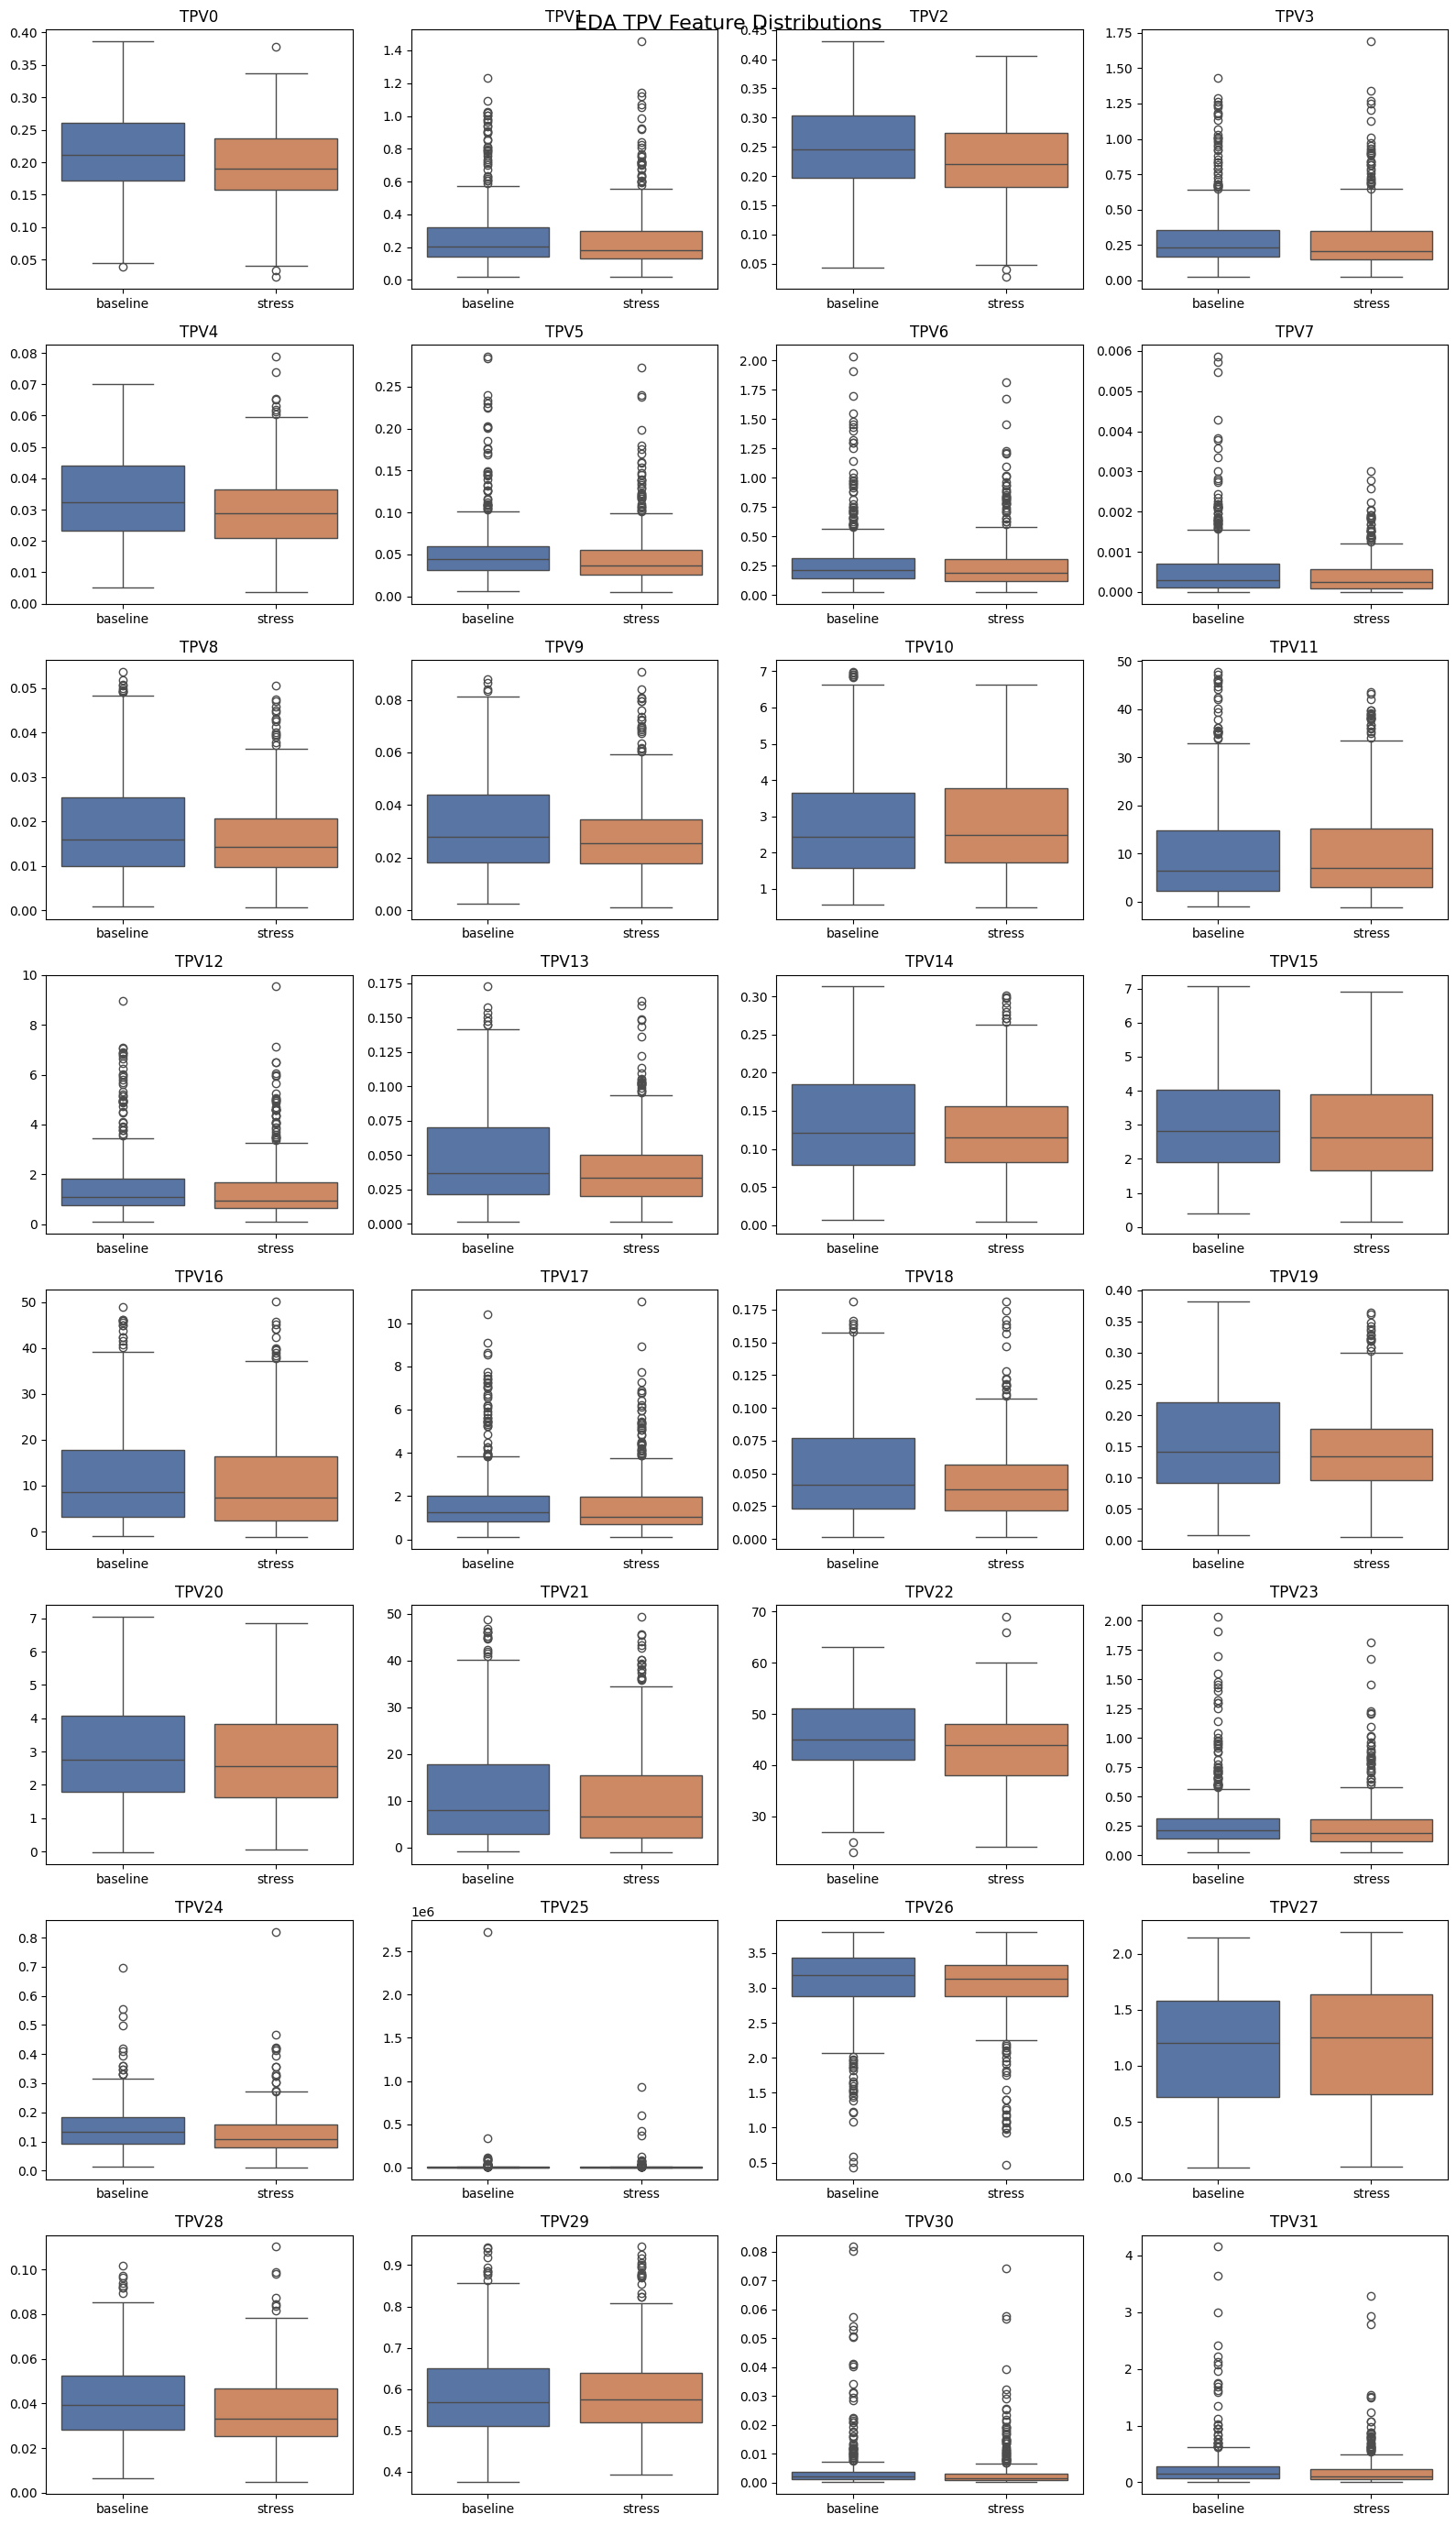


===== EDA TPV Summary =====
feature   Baseline (mean±std)    Stress (mean±std)         direction  anova_p
   TPV2         0.248 ± 0.074        0.225 ± 0.069 stress < baseline 0.000002
  TPV22        45.610 ± 7.152       43.362 ± 7.035 stress < baseline 0.000003
   TPV0         0.214 ± 0.062        0.195 ± 0.058 stress < baseline 0.000003
   TPV4         0.034 ± 0.014        0.030 ± 0.013 stress < baseline 0.000004
  TPV13         0.049 ± 0.036        0.040 ± 0.028 stress < baseline 0.000070
  TPV18         0.054 ± 0.040        0.045 ± 0.031 stress < baseline 0.000088
   TPV9         0.033 ± 0.018        0.028 ± 0.016 stress < baseline 0.000098
   TPV8         0.019 ± 0.011        0.016 ± 0.009 stress < baseline 0.000221
  TPV28         0.041 ± 0.017        0.037 ± 0.017 stress < baseline 0.000236
  TPV24         0.144 ± 0.078        0.126 ± 0.080 stress < baseline 0.000582
  TPV19         0.160 ± 0.087        0.143 ± 0.071 stress < baseline 0.001580
  TPV14         0.135 ± 0.071      

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import f_oneway

# -------------------------
# load
# -------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/EDA_TPV/StressPredict_EDA_TPV_noQC.csv")

# -------------------------
# state mapping
# -------------------------
df["state"] = df["status_name"].replace({
    "normal": "baseline",
    "stress": "stress"
})

# -------------------------
# TPV 자동 선택
# -------------------------
tpv_features = [c for c in df.columns if c.startswith("TPV")]

print(f"Total TPV features: {len(tpv_features)}")

results = []

# -------------------------
# boxplot
# -------------------------
n_features = len(tpv_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]

    anova = f_oneway(b, s)
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline","mean"],
        "baseline_std": summary.loc["baseline","std"],
        "stress_mean": summary.loc["stress","mean"],
        "stress_std": summary.loc["stress","std"],
        "direction": "stress > baseline" if summary.loc["stress","mean"] > summary.loc["baseline","mean"] else "stress < baseline",
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA TPV Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df = results_df[
    ["feature","Baseline (mean±std)","Stress (mean±std)","direction","anova_p"]
].sort_values("anova_p")

print("\n===== EDA TPV Summary =====")
print(results_df.to_string(index=False))

# 3. IBI -> HRV

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

from scipy.signal import welch
from numpy import trapezoid
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/Stress-Predict-Dataset/Raw_data"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/HRV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"S17"}

WINDOW_SEC = 60
STEP_SEC = 60
MAJORITY_RATIO_MIN = 0.95

FS_IBI_INTERP = 4.0
LF_LOW = 0.04
LF_HIGH = 0.15
HF_LOW = 0.15
HF_HIGH = 0.40

IBI_MIN_SEC = 0.30
IBI_MAX_SEC = 1.50
IBI_DIFF_RATIO_MAX = 0.30

# =============================================================================
# Loaders
# =============================================================================
def load_ibi_csv(file_path):
    raw = pd.read_csv(file_path, header=None)
    start_ts = float(str(raw.iloc[0, 0]).strip())

    data = raw.iloc[1:, :2].copy()
    data.columns = ["relative_time", "ibi"]
    data = data.dropna()

    data["relative_time"] = data["relative_time"].astype(float)
    data["ibi"] = data["ibi"].astype(float)
    data["timestamp"] = start_ts + data["relative_time"]

    return data[["timestamp", "relative_time", "ibi"]], start_ts


def load_tags_csv(file_path, drop_first_tag=True):
    """
    tags_SXX.csv:
    - 각 행이 timestamp 하나
    - 일부 subject(S18, S30 등)는 첫 tag가 실제 baseline 시작이 아니라
      훨씬 이전의 기록 시작 시점이라 baseline을 비정상적으로 길게 만드는 문제가 있음
    - 따라서 첫 tag 제거 옵션을 기본으로 사용
    """
    raw = pd.read_csv(file_path, header=None)

    tags = raw.iloc[:, 0].dropna().astype(float).reset_index(drop=True)

    if drop_first_tag:
        if len(tags) <= 1:
            raise ValueError(f"Not enough tags after dropping first tag: n={len(tags)}")
        tags = tags.iloc[1:].reset_index(drop=True)

    return pd.DataFrame({
        "tag_idx": np.arange(len(tags)),
        "timestamp": tags
    })


# =============================================================================
# Protocol intervals
# =============================================================================
def build_protocol_intervals(tags_df):
    """
    Stress-Predict protocol (after dropping the spurious first tag):
      t0~t1 : Baseline        -> 0
      t1~t2 : Stroop          -> 1
      t2~t3 : Rest1           -> 0
      t3~t4 : TSST            -> 1
      t4~t5 : Rest2           -> 0
      t5~t6 : Hyperventilation-> 1
      t6~t7 : Rest3           -> 0
      t7~t8 : Questionnaire   -> 0
    """
    timestamps = tags_df["timestamp"].values

    phase_info = [
        ("Baseline", 0),
        ("Stroop", 1),
        ("Rest1", 0),
        ("TSST", 1),
        ("Rest2", 0),
        ("Hyperventilation", 1),
        ("Rest3", 0),
        ("Questionnaire", 0),
    ]

    n_intervals_possible = len(timestamps) - 1
    n_use = min(n_intervals_possible, len(phase_info))

    if n_use <= 0:
        raise ValueError(f"No valid intervals from tags. n_tags={len(timestamps)}")

    rows = []
    for i in range(n_use):
        phase_name, label = phase_info[i]
        rows.append({
            "interval_idx": i,
            "phase": phase_name,
            "start": timestamps[i],
            "end": timestamps[i + 1],
            "label": label
        })

    return pd.DataFrame(rows)


def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60, majority_ratio_min=0.95):
    """
    현재는 interval 내부에서만 window를 자르므로 major_ratio는 사실상 1.0
    구조 통일을 위해 컬럼 유지
    """
    rows = []

    for _, r in intervals_df.iterrows():
        start = float(r["start"])
        end = float(r["end"])
        phase = r["phase"]
        label = int(r["label"])

        t = start
        while t + window_sec <= end:
            rows.append({
                "phase": phase,
                "label": label,
                "window_start": t,
                "window_end": t + window_sec,
                "major_ratio": 1.0
            })
            t += step_sec

    return pd.DataFrame(rows)


# =============================================================================
# HRV helpers
# =============================================================================
def safe_div(a, b):
    return float(a / b) if abs(b) > 1e-12 else np.nan


def build_filtered_ibi_series(ibi_times_abs, ibi_values):
    ibi_times_abs = np.asarray(ibi_times_abs, dtype=np.float64).reshape(-1)
    ibi_values = np.asarray(ibi_values, dtype=np.float64).reshape(-1)

    if len(ibi_times_abs) < 2 or len(ibi_values) < 2:
        return None

    plausible = (ibi_values >= IBI_MIN_SEC) & (ibi_values <= IBI_MAX_SEC)
    ibi_values = ibi_values[plausible]
    ibi_times_abs = ibi_times_abs[plausible]

    if len(ibi_values) < 2:
        return None

    med_ibi = float(np.median(ibi_values))
    stable = np.abs(ibi_values - med_ibi) <= (IBI_DIFF_RATIO_MAX * (med_ibi + 1e-8))

    ibi_values = ibi_values[stable]
    ibi_times_abs = ibi_times_abs[stable]

    if len(ibi_values) < 2:
        return None

    return {
        "ibi_times_abs": ibi_times_abs,
        "ibi": ibi_values,
        "ibi_median_sec": med_ibi
    }


def interpolate_ibi(ibi_times_abs, ibi, fs_interp=FS_IBI_INTERP):
    ibi_times_abs = np.asarray(ibi_times_abs, dtype=np.float64).reshape(-1)
    ibi = np.asarray(ibi, dtype=np.float64).reshape(-1)

    if len(ibi_times_abs) < 2 or len(ibi) < 2:
        return None
    if ibi_times_abs[-1] <= ibi_times_abs[0]:
        return None

    t_uniform = np.arange(ibi_times_abs[0], ibi_times_abs[-1], 1.0 / fs_interp)
    if len(t_uniform) < 4:
        return None

    try:
        f_interp = interp1d(
            ibi_times_abs,
            ibi,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
            assume_sorted=True
        )
        ibi_uniform = f_interp(t_uniform)
    except Exception:
        return None

    ibi_uniform = np.asarray(ibi_uniform, dtype=np.float64)
    if np.any(~np.isfinite(ibi_uniform)):
        return None

    return {"t_uniform": t_uniform, "ibi_uniform": ibi_uniform}


def compute_time_domain_hrv(ibi):
    ibi = np.asarray(ibi, dtype=np.float64).reshape(-1)

    if len(ibi) < 2:
        return {
            "RMSSD": np.nan,
            "SDNN": np.nan,
            "ibi_mean_sec": np.nan,
            "ibi_std_sec": np.nan,
        }

    diff_ibi = np.diff(ibi)
    rmssd = np.sqrt(np.mean(diff_ibi ** 2)) if len(diff_ibi) > 0 else np.nan
    sdnn = np.std(ibi, ddof=0)

    return {
        "RMSSD": float(rmssd) if np.isfinite(rmssd) else np.nan,
        "SDNN": float(sdnn) if np.isfinite(sdnn) else np.nan,
        "ibi_mean_sec": float(np.mean(ibi)) if np.isfinite(np.mean(ibi)) else np.nan,
        "ibi_std_sec": float(np.std(ibi, ddof=0)) if np.isfinite(np.std(ibi, ddof=0)) else np.nan,
    }


def compute_freq_domain_hrv(ibi_uniform, fs_interp=FS_IBI_INTERP):
    ibi_uniform = np.asarray(ibi_uniform, dtype=np.float64).reshape(-1)
    if len(ibi_uniform) < 8:
        return {"LF": np.nan, "HF": np.nan, "LF_HF": np.nan}

    nperseg = min(256, len(ibi_uniform))
    f, pxx = welch(ibi_uniform, fs=fs_interp, nperseg=nperseg)

    lf_mask = (f >= LF_LOW) & (f < LF_HIGH)
    hf_mask = (f >= HF_LOW) & (f < HF_HIGH)

    lf = np.trapezoid(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
    hf = np.trapezoid(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan
    lf_hf = safe_div(lf, hf) if np.isfinite(lf) and np.isfinite(hf) else np.nan

    return {
        "LF": float(lf) if np.isfinite(lf) else np.nan,
        "HF": float(hf) if np.isfinite(hf) else np.nan,
        "LF_HF": float(lf_hf) if np.isfinite(lf_hf) else np.nan,
    }


def extract_hrv_features_from_ibi_segment(seg_ibi_df):
    ibi_times_abs = seg_ibi_df["timestamp"].values
    ibi_values = seg_ibi_df["ibi"].values

    row = {
        "n_ibi": int(len(ibi_values)),
        "ibi_pass_ratio": np.nan,
        "valid_ibi_count": 0,
        "ibi_mean_sec": np.nan,
        "ibi_std_sec": np.nan,
        "RMSSD": np.nan,
        "SDNN": np.nan,
        "LF": np.nan,
        "HF": np.nan,
        "LF_HF": np.nan,
    }

    if len(ibi_values) < 2:
        return row

    plausible = (ibi_values >= IBI_MIN_SEC) & (ibi_values <= IBI_MAX_SEC)
    row["ibi_pass_ratio"] = float(np.mean(plausible)) if len(ibi_values) > 0 else np.nan

    pack = build_filtered_ibi_series(ibi_times_abs, ibi_values)
    if pack is None:
        return row

    ibi = pack["ibi"]
    ibi_times_abs = pack["ibi_times_abs"]
    row["valid_ibi_count"] = int(len(ibi))

    td = compute_time_domain_hrv(ibi)
    row.update(td)

    interp_pack = interpolate_ibi(ibi_times_abs, ibi, fs_interp=FS_IBI_INTERP)
    if interp_pack is None:
        return row

    fd = compute_freq_domain_hrv(interp_pack["ibi_uniform"], fs_interp=FS_IBI_INTERP)
    row.update(fd)
    return row


# =============================================================================
# Main extraction
# =============================================================================
def extract_subject_ibi_hrv(subject_dir):
    subject_id = os.path.basename(subject_dir)
    if subject_id in EXCLUDE_SUBJECTS:
        return pd.DataFrame()

    ibi_path = os.path.join(subject_dir, "IBI.csv")
    tags_path = os.path.join(subject_dir, f"tags_{subject_id}.csv")

    if not (os.path.exists(ibi_path) and os.path.exists(tags_path)):
        return pd.DataFrame()

    ibi_df, _ = load_ibi_csv(ibi_path)
    tags_df = load_tags_csv(tags_path, drop_first_tag=True)

    # tags가 너무 적으면 skip
    if len(tags_df) < 2:
        print(f"[WARN] {subject_id}: too few tags after dropping first tag")
        return pd.DataFrame()

    intervals_df = build_protocol_intervals(tags_df)
    window_df = build_window_table_from_intervals(
        intervals_df,
        WINDOW_SEC,
        STEP_SEC,
        MAJORITY_RATIO_MIN
    )

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        seg_ibi_df = ibi_df[(ibi_df["timestamp"] >= t0) & (ibi_df["timestamp"] < t1)].copy()
        hrv_info = extract_hrv_features_from_ibi_segment(seg_ibi_df)

        window_counter += 1
        row = {
            "subject": subject_id,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "window_sec": WINDOW_SEC,
            "status": int(w["label"]),
            "status_name": "stress" if int(w["label"]) == 1 else "normal",
            "phase": w["phase"],
            "t_start_sec": t0,
            "t_end_sec": t1,
            "major_ratio": float(w["major_ratio"])
        }
        row.update(hrv_info)
        rows.append(row)

    return pd.DataFrame(rows)


def main():
    subject_dirs = sorted([d for d in glob.glob(os.path.join(ROOT_DIR, "S*")) if os.path.isdir(d)])
    all_dfs = []

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    for subject_dir in subject_dirs:
        sid = os.path.basename(subject_dir)
        if sid in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {sid}")
            continue

        print(f"[INFO] Processing {sid} ...")
        try:
            df_sub = extract_subject_ibi_hrv(subject_dir)
            print(f"[INFO] {sid}: extracted {len(df_sub)} windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {sid}: {e}")

    if len(all_dfs) == 0:
        print("[WARN] No windows extracted.")
        return

    df_all = pd.concat(all_dfs, axis=0, ignore_index=True)

    base_cols = [
        "subject", "window", "window_index", "window_sec",
        "status", "status_name", "phase",
        "t_start_sec", "t_end_sec", "major_ratio"
    ]
    hrv_cols = [
        "n_ibi",
        "ibi_pass_ratio",
        "valid_ibi_count",
        "ibi_mean_sec",
        "ibi_std_sec",
        "RMSSD",
        "SDNN",
        "LF",
        "HF",
        "LF_HF",
    ]

    df_all = df_all[base_cols + hrv_cols].copy()

    csv_path = os.path.join(OUTPUT_DIR, "StressPredict_IBI_HRV_1min.csv")
    df_all.to_csv(csv_path, index=False)

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_windows=("window", "count"),
            n_valid_rmssd=("RMSSD", lambda x: int(np.sum(np.isfinite(x)))),
            n_valid_lf_hf=("LF_HF", lambda x: int(np.sum(np.isfinite(x)))),
        )
        .reset_index()
    )
    summary_csv = os.path.join(OUTPUT_DIR, "StressPredict_IBI_HRV_1min_summary.csv")
    summary.to_csv(summary_csv, index=False)

    print(f"[INFO] Saved: {csv_path}")
    print(f"[INFO] Saved: {summary_csv}")
    print("\n[INFO] Status counts")
    print(df_all["status_name"].value_counts())


if __name__ == "__main__":
    main()

[INFO] Found 35 subject folders
[INFO] Processing S01 ...
[INFO] S01: extracted 44 windows
[INFO] Processing S02 ...
[INFO] S02: extracted 40 windows
[INFO] Processing S03 ...
[INFO] S03: extracted 38 windows
[INFO] Processing S04 ...
[INFO] S04: extracted 40 windows
[INFO] Processing S05 ...
[INFO] S05: extracted 25 windows
[INFO] Processing S06 ...
[INFO] S06: extracted 25 windows
[INFO] Processing S07 ...
[INFO] S07: extracted 26 windows
[INFO] Processing S08 ...
[INFO] S08: extracted 23 windows
[INFO] Processing S09 ...
[INFO] S09: extracted 25 windows
[INFO] Processing S10 ...
[INFO] S10: extracted 25 windows
[INFO] Processing S11 ...
[INFO] S11: extracted 25 windows
[INFO] Processing S12 ...
[INFO] S12: extracted 25 windows
[INFO] Processing S13 ...
[INFO] S13: extracted 26 windows
[INFO] Processing S14 ...
[INFO] S14: extracted 26 windows
[INFO] Processing S15 ...
[INFO] S15: extracted 28 windows
[INFO] Processing S16 ...
[INFO] S16: extracted 26 windows
[INFO] Skip excluded sub

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/HRV/StressPredict_IBI_HRV_1min.csv")
print(df.groupby(["subject", "status_name"]).size().unstack(fill_value=0))

status_name  normal  stress
subject                    
S01              28      16
S02              23      17
S03              24      14
S04              23      17
S05              13      12
S06              17       8
S07              14      12
S08              13      10
S09              15      10
S10              14      11
S11              13      12
S12              13      12
S13              15      11
S14              14      12
S15              15      13
S16              15      11
S18              15      12
S19              16       8
S20              14      10
S21              14      11
S22              13      11
S23              14      11
S24              14      11
S25              14      10
S26              13      11
S27              13      11
S28              13      12
S29              14      10
S30              14      11
S31              14      10
S32              15      10
S33              12      12
S34              14      11
S35              15 

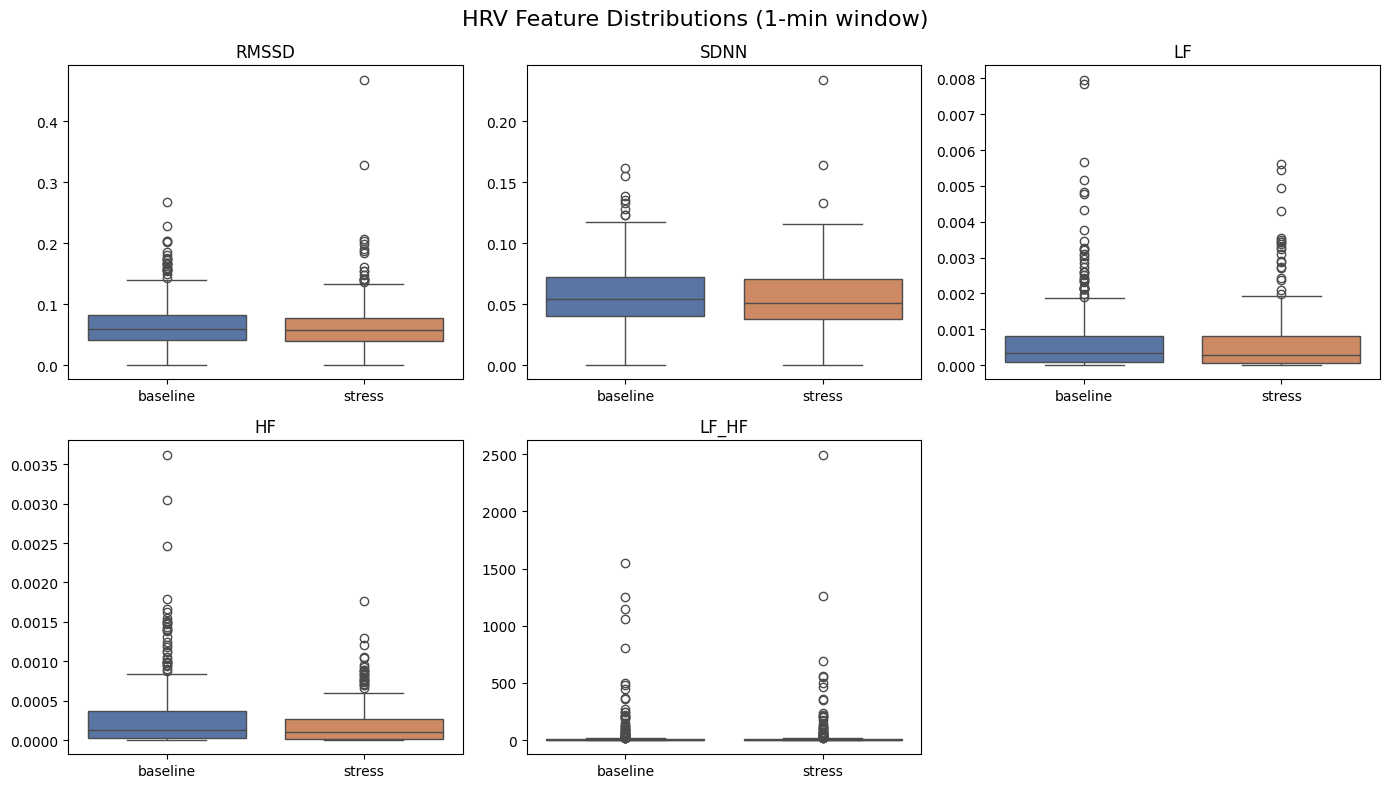


===== HRV Feature Summary =====
feature Baseline (mean±std) Stress (mean±std)         direction  anova_p
  RMSSD       0.067 ± 0.037     0.065 ± 0.044 stress < baseline 0.649311
   SDNN       0.058 ± 0.025     0.054 ± 0.026 stress < baseline 0.074088
     LF       0.001 ± 0.001     0.001 ± 0.001 stress < baseline 0.673347
     HF       0.000 ± 0.000     0.000 ± 0.000 stress < baseline 0.002862
  LF_HF    33.838 ± 146.074  39.795 ± 186.069 stress > baseline 0.644907


In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# -------------------------
# load
# -------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Stress-Predict-Dataset/HRV/StressPredict_IBI_HRV_1min.csv")

if "state" in df.columns:
    df["state"] = df["state"]
else:
    df["state"] = df["status_name"].replace({
        "normal": "baseline",
        "stress": "stress"
    })

# -------------------------
# HRV features
# -------------------------
hrv_features = ["RMSSD", "SDNN", "LF", "HF", "LF_HF"]

results = []

# -------------------------
# Figure (5 boxplots)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(hrv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]

    anova = f_oneway(b, s)
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline","mean"],
        "baseline_std": summary.loc["baseline","std"],
        "stress_mean": summary.loc["stress","mean"],
        "stress_std": summary.loc["stress","std"],
        "direction": "stress > baseline" if summary.loc["stress","mean"] > summary.loc["baseline","mean"] else "stress < baseline",
        "anova_p": anova.pvalue
    })

# 마지막 subplot 제거
fig.delaxes(axes[-1])

plt.suptitle("HRV Feature Distributions (1-min window)", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df = results_df[
    ["feature","Baseline (mean±std)","Stress (mean±std)","direction","anova_p"]
]

print("\n===== HRV Feature Summary =====")
print(results_df.to_string(index=False))